# Tabelas F1 score da classificação

In [ ]:
import pandas as pd

In [ ]:
# df = pd.read_csv('results/pu_classify_results_Cora.csv')
# df = pd.read_csv('results/final_pu_classify_results_CiteSeer.csv')
# df = pd.read_csv('results/final_pu_classify_results_PubMed.csv')
# df = pd.read_csv('results/pu_classify_results_Photo.csv')
# df = pd.read_csv('results/pu_classify_results_dblp.csv')

df = pd.read_csv('results/final_gnn_neg_inf_results_PubMed.csv')



In [ ]:
df.columns

In [ ]:
import pandas as pd

df_grouped = df.groupby(['rate', 'model'])['f1'].agg(
    f1='mean',
    f1_std='std'
).reset_index()


In [ ]:
model_name = 'DropEdgeGCN'

In [ ]:
df_grouped[df_grouped['model'] ==model_name]

In [ ]:
def format_f1_with_std(df):
    return df.apply(lambda row: f"{round(row['f1'], 4)} ± {round(row['f1_std'], 2)}", axis=1)

In [ ]:
latex_df = df_grouped[df_grouped['model'] == model_name][['f1', 'f1_std']]


latex_df['f1_fmt'] = format_f1_with_std(latex_df)

output_str = ''

for value in latex_df['f1_fmt']:
    output_str += value + ' & ' 

output_str = output_str[:-2]
output_str = model_name + '&  ' + output_str + r'\\hline'


output_str

In [ ]:
df_grouped[df_grouped['rate'] == 0.01]

In [ ]:
df_grouped[df_grouped['rate'] == 0.05]

In [ ]:
df_grouped[df_grouped['rate'] == 0.1]

In [ ]:
df_grouped[df_grouped['rate'] == 0.15]

In [ ]:
df_grouped[df_grouped['rate'] == 0.2]

In [ ]:
df_grouped[df_grouped['rate'] == 0.25]

# Analysis neg_inf

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

dataset_name = 'CiteSeer'


# df_neurais = pd.read_csv(f'results/final_gnn_neg_inf_results_{dataset_name}.csv')
df_neurais = pd.read_csv(f'results/final_gnn_neg_inf_results_Photo.csv')
df_concorrentes = pd.read_csv(f'results/neg_inf_results_{dataset_name}.csv')

df = pd.concat([df_neurais, df_concorrentes])

In [11]:
cores_modelos = {
    'RGCN': '#1f77b4',  # Azul
    'GCN': '#ff7f0e',    # Laranja
    'SkipNodeGCN': '#2ca02c',  # Verde
    'DropEdgeGCN': '#d62728',  # Vermelho
    'MCLS': '#9467bd',   # Roxo
    'PU_LP': '#8c564b',   # Marrom
    'LP_PUL': '#e377c2',  # Rosa
    'CCRNE': '#7f7f7f',   # Cinza
    'RCSVM': '#bcbd22',   # Amarelo
}

## Modelos Neurais

In [12]:
modelos_neurais = ['RGCN', 'GCN', 'DropEdgeGCN', 'SkipNodeGCN']
# Filtra o DataFrame apenas com os modelos presentes na lista
df_neurais = df[df['model'].isin(modelos_neurais)].copy()

# Verifique o resultado
print(df_neurais.head())

   Unnamed: 0     acc      f1  precision  recall  1/1   0/0  0/1   1/0  \
0           0  0.6842  0.8125     0.6842     1.0  0.0  13.0  0.0   6.0   
1           1  0.6842  0.8125     0.6842     1.0  0.0  13.0  0.0   6.0   
2           2  0.8421  0.9143     0.8421     1.0  0.0  16.0  0.0   3.0   
3           3  0.6842  0.8125     0.6842     1.0  0.0  13.0  0.0   6.0   
4           4  0.7368  0.8485     0.7368     1.0  0.0  28.0  0.0  10.0   

         model dataset  rate  length negatives  length positives  
0         RGCN   Photo  0.01                19                19  
1          GCN   Photo  0.01                19                19  
2  SkipNodeGCN   Photo  0.01                19                19  
3  DropEdgeGCN   Photo  0.01                19                19  
4         RGCN   Photo  0.02                38                38  


[]

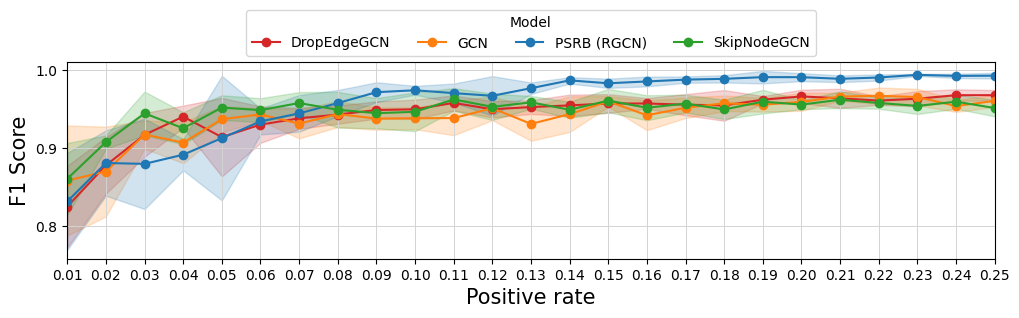

In [13]:
# Agrupar por 'rate' e 'model', e calcular média e desvio padrão
summary = df_neurais.groupby(['rate', 'model'])['f1'].agg(['mean', 'std']).reset_index()

# Lista de modelos únicos
modelos = summary['model'].unique()

# Plot
plt.figure(figsize=(10.3, 3.5))  # largura exata, altura ajustável conforme necessário

for model in modelos:
    dados_modelo = summary[summary['model'] == model]
    rates = dados_modelo['rate']
    medias = dados_modelo['mean']
    desvios = dados_modelo['std']
    
    cor = cores_modelos.get(model, '#000000')

    # Trocar o nome 'RGCN' por 'PSRB (RGCN)' na legenda
    if model == 'RGCN':
        label = 'PSRB (RGCN)'
    else:
        label = model
    
    # Linha principal (média do F1)
    plt.plot(rates, medias, label=label, marker='o', color = cor)
    
    # Faixa do desvio padrão (transparente)
    plt.fill_between(rates, medias - desvios, medias + desvios, alpha=0.2, color = cor)


# Ajustar limites do eixo X para 0.01 a 0.25
plt.xlim(0.01, 0.25)
# plt.ylim(0.4,1.1)

plt.xlabel('Positive rate', fontsize = 15)
plt.ylabel('F1 Score', fontsize = 15)
# plt.title('Desempenho dos modelos com diferentes taxas de dados rotulados')
# plt.legend(title='Model', fontsize = 10)
plt.legend(title='Model', bbox_to_anchor=(0.5, 1.3), loc='upper center', ncol=7)
plt.xticks(ticks=[x/100 for x in range(1,26)],fontsize=10)
plt.yticks(fontsize=10, ticks = [0.4,0.5,0.6,0.7,0.8,0.9,1])
plt.grid(True, color='lightgray', linewidth=0.7, which='both')
plt.tight_layout()
plt.savefig(f'plots/neg_inf_{dataset_name}_neural2.svg', format='svg')
plt.plot()

In [5]:
modelos_nao_neurais = ['RGCN', 'CCRNE', 'MCLS', 'LP_PUL', 'PU_LP', 'RCSVM']
# Filtra o DataFrame apenas com os modelos presentes na lista
df_nao_neurais = df[df['model'].isin(modelos_nao_neurais)].copy()

# Verifique o resultado
print(df_nao_neurais.head())

    Unnamed: 0     acc      f1  precision  recall  1/1   0/0  0/1  1/0 model  \
0            0  0.8333  0.9091     0.8333     1.0  0.0   5.0  0.0  1.0  RGCN   
4            4  0.9231  0.9600     0.9231     1.0  0.0  12.0  0.0  1.0  RGCN   
8            8  0.9000  0.9474     0.9000     1.0  0.0  18.0  0.0  2.0  RGCN   
12          12  0.9615  0.9804     0.9615     1.0  0.0  25.0  0.0  1.0  RGCN   
16          16  0.9697  0.9846     0.9697     1.0  0.0  32.0  0.0  1.0  RGCN   

     dataset  rate  length negatives  length positives  
0   CiteSeer  0.01                 6                 6  
4   CiteSeer  0.02                13                13  
8   CiteSeer  0.03                20                20  
12  CiteSeer  0.04                26                26  
16  CiteSeer  0.05                33                33  


[]

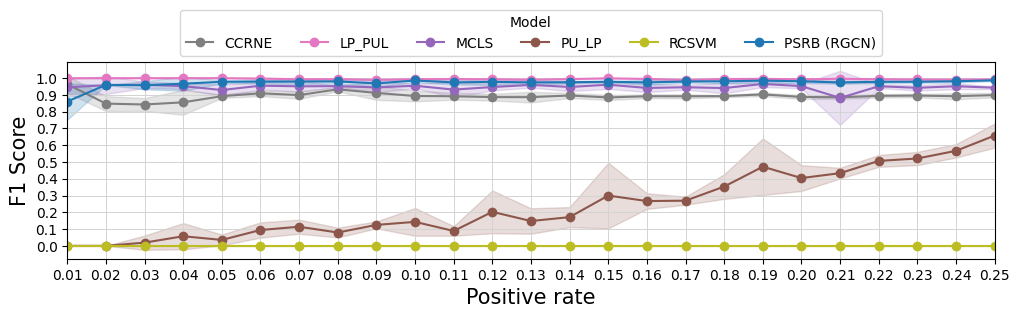

In [6]:
# Agrupar por 'rate' e 'model', e calcular média e desvio padrão
summary = df_nao_neurais.groupby(['rate', 'model'])['f1'].agg(['mean', 'std']).reset_index()

# Lista de modelos únicos
modelos = summary['model'].unique()

# Plot
plt.figure(figsize=(10.3, 3.5))  # largura exata, altura ajustável conforme necessário

for model in modelos:
    dados_modelo = summary[summary['model'] == model]
    rates = dados_modelo['rate']
    medias = dados_modelo['mean']
    desvios = dados_modelo['std']
    
    cor = cores_modelos.get(model, '#000000')

    # Trocar o nome 'RGCN' por 'PSRB (RGCN)' na legenda
    if model == 'RGCN':
        label = 'PSRB (RGCN)'
    else:
        label = model
    
    # Linha principal (média do F1)
    plt.plot(rates, medias, label=label, marker='o', color = cor)
    
    # Faixa do desvio padrão (transparente)
    plt.fill_between(rates, medias - desvios, medias + desvios, alpha=0.2, color = cor)


# Ajustar limites do eixo X para 0.01 a 0.25
plt.xlim(0.01, 0.25)
# plt.ylim(0.4,1.1)

plt.xlabel('Positive rate', fontsize = 15)
plt.ylabel('F1 Score', fontsize = 15)
# plt.title('Desempenho dos modelos com diferentes taxas de dados rotulados')
# Ajustar a posição e formato da legenda
# plt.legend(
#     title='Modelo',
#     fontsize=10,
#     loc='upper center',  # Coloca a legenda na parte superior
#     bbox_to_anchor=(0.5, 1.15),  # Move a legenda um pouco para cima
#     borderpad=1,  # Aumenta a largura da caixa
#     handlelength=2,  # Aumenta o comprimento das linhas da legenda
#     labelspacing=1.2  # Aumenta o espaçamento entre os itens da legenda
# )
plt.legend(title='Model', bbox_to_anchor=(0.5, 1.3), loc='upper center', ncol=7)
plt.xticks(ticks=[x/100 for x in range(1,26)],fontsize=10)
plt.yticks(fontsize=10, ticks = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1])
plt.grid(True, color='lightgray', linewidth=0.7, which='both')
plt.tight_layout()
plt.savefig(f'plots/neg_inf_{dataset_name}_nao_neural.svg', format='svg')
plt.plot()

# Análise de épocas

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd

# Carregar e agregar os dados
df = pd.read_csv('results/epochs_results_Cora.csv')
df = df[df['model'] == 'RGCN']
df_avg = df.groupby(['epochs_pu', 'epochs_neginf'], as_index=False)['f1'].mean()
pivot = df_avg.pivot(index='epochs_pu', columns='epochs_neginf', values='f1')

# Preparar malha
ep1 = pivot.columns.to_numpy()
ep2 = pivot.index.to_numpy()
Ep1, Ep2 = np.meshgrid(ep1, ep2)
F1 = pivot.to_numpy()

# Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Escolher um colormap mais vibrante
surf = ax.plot_surface(Ep1, Ep2, F1, cmap='plasma', edgecolor='k', linewidth=0.3, antialiased=True)

# Ajuste dos rótulos
ax.set_xlabel('Epochs Negative Inference', fontsize=20)
ax.set_ylabel('Epochs PU Classification', fontsize=20)
ax.set_zlabel('F1 Score', fontsize=20)
# plt.title('F1 Score por Épocas dos Modelos', fontsize=14)

# Barra de cores para indicar escala
fig.colorbar(surf, shrink=0.5, aspect=10)

# Ajuste da visão (ângulo de inclinação e rotação)
ax.view_init(elev=30, azim=135)

plt.tight_layout()
plt.savefig(f'plots/epochs_cora_rgcn.svg', format='svg')
# plt.plot()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd

# Carregar e agregar os dados
df = pd.read_csv('results/epochs_results_Cora.csv')
df = df[df['model'] == 'GCN']
df_avg = df.groupby(['epochs_pu', 'epochs_neginf'], as_index=False)['f1'].mean()
# df_avg = df_avg[df_avg['f1'] > 0.1]
pivot = df_avg.pivot(index='epochs_pu', columns='epochs_neginf', values='f1')

# Preparar malha
ep1 = pivot.columns.to_numpy()
ep2 = pivot.index.to_numpy()
Ep1, Ep2 = np.meshgrid(ep1, ep2)
F1 = pivot.to_numpy()

# Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Escolher um colormap mais vibrante
surf = ax.plot_surface(Ep1, Ep2, F1, cmap='plasma', edgecolor='k', linewidth=0.3, antialiased=True)

# Ajuste dos rótulos
ax.set_xlabel('Epochs Negative Inference', fontsize=20)
ax.set_ylabel('Epochs PU Classification', fontsize=20)
ax.set_zlabel('F1 Score', fontsize=20)
# plt.title('F1 Score por Épocas dos Modelos', fontsize=14)

# Barra de cores para indicar escala
fig.colorbar(surf, shrink=0.5, aspect=10)

# Ajuste da visão (ângulo de inclinação e rotação)
ax.view_init(elev=30, azim=135)

plt.tight_layout()
plt.savefig(f'plots/epochs_cora_gcn.svg', format='svg')
# plt.plot()
plt.show()
